In [7]:
%matplotlib inline
from brian2 import *
import numpy as np
import math
from scipy.stats import kstest, norm
import pandas
import seaborn as sns
import statistics as stats
import sys
from IPython.display import clear_output

### w_Ew sampling & winner count distribution

In [12]:
#從特定的常態分配抽樣，並分派給所有的w_Ew
n=31
Wstd=9
w_Ew=284.331

w_Ew_randn=[]
for i in np.arange(2*n-2,(n-1)*6):
    w_Ew_randn.append( w_Ew + Wstd*np.random.randn() )

Success Rate: 0.9
{7: 0.0, 10: 0.0, 11: 0.0, 17: 0.0, 19: 0.0, 21: 0.0, 28: 0.0, 1: 1.0, 5: 1.0, 13: 2.0, 23: 2.0, 24: 2.0, 27: 2.0, 26: 5.0, 14: 6.0, 4: 7.0, 25: 8.0, 30: 8.0, 29: 10.0, 8: 11.0, 9: 11.0, 22: 13.0, 18: 14.0, 20: 17.0, 12: 23.0, 6: 26.0, 2: 54.0, 15: 56.0, 16: 69.0, 3: 102.0}


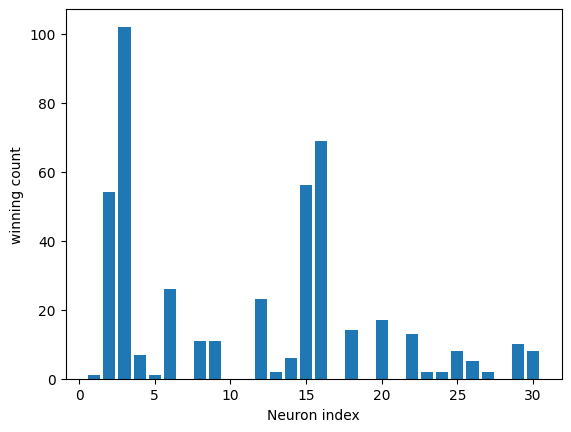

In [9]:
# Defining Presenting Order
start_scope()

n=31
N_Trial=500

acc=range(N_Trial)
victory_count=np.zeros(n-1)
suc=0
for trial in acc:
    test_set=[]
    control=[]
    L=2 #local domain
    U=L+1

    #initial conditions
    light=0       ###10^-8


    n=31 #num of neurons
    jump=2 #spacing

    slope=5               
    t=46*ms           
    threshold=540
    mean=110 ##
    std=400   ##      

    w_I=-380      
    w_Eb=20           
    w_Ew=292.5 ## 


    #simulation
    eqs='''
    dr/dt = ( - r + 1/(1+exp(-a*(Isyn+Iin-theta+mu+sigma*randn())))) / tau : 1
    Iin : 1
    Isyn : 1
    theta : 1
    a : 1
    sigma : 1
    tau : second
    mu : 1
    '''

    G=NeuronGroup(n, eqs, method='euler');


    G.r = 0.0
    G.tau=t
    G.Iin=0
    G.Iin[15]=light
    G.theta=threshold
    G.a=slope
    G.mu=mean
    G.sigma=std


    S = Synapses(G, G, '''
                w : 1 # synaptic weight
                Isyn_post = w * r_pre : 1 (summed)
                ''')

    I=[];J=[]
    for syn in range(1,n):
        I.append(syn)
        J.append(0)
    for syn in range(1,n):
        I.append(0)
        J.append(syn)

    for syn in range(1,n):
        if syn < (n-1):
            I.append(syn)
            J.append(syn+1)
        else:
            I.append(syn)
            J.append(1)
    if n>3:
        for syn in range(n-1,0,-1):
            if syn>1:
                I.append(syn)
                J.append(syn-1)
            else:
                I.append(syn)
                J.append(n-1)
    if n>4:
        for syn in range(1,n):
            if (syn+jump) <= (n-1):
                I.append(syn)
                J.append(syn+jump)
            else:
                I.append(syn)
                J.append(syn-(n-1-jump))
    if n>5:
        for syn in range(n-1,0,-1):
            if syn>jump:
                I.append(syn)
                J.append(syn-2)
            else:
                I.append(syn)
                J.append(syn+(n-1-jump))



    S.connect(i=I,j=J)

    for syn in np.arange(n-1):
        S.w[syn]=w_Eb


    for syn in np.arange(n-1, 2*n-2):
        S.w[syn]=w_I

    i=0
    for syn in np.arange(2*n-2,len(S.w)):
        S.w[syn]=w_Ew_randn[i]
        i+=1

    M = StateMonitor(G, 'r', record=True)

    run(3500*ms)
    MAX=np.argmax(np.mean(M.r[1:31,20000:],axis=1))+1
    if 0.1<np.mean(M.r[1:31,20000:])<0.68 and np.mean(M.r[MAX][20000:])>0.6: 
        victory_count[MAX-1]+=1
        suc+=1
    print(f'Trial{trial}')
    clear_output(wait=True)

success_rate=round(suc/N_Trial,2)
print(f'Success Rate: {success_rate}');
bar(range(1,n), victory_count);
xlabel('Neuron index');
ylabel('winning count');




my_dict = {index+1: value for index, value in enumerate(victory_count)}

# Sort dictionary by values
sorted_dict = dict(sorted(my_dict.items(), key=lambda item: item[1], reverse=False))

print(sorted_dict)

indexs=list(sorted_dict.keys())

### 1. My approach

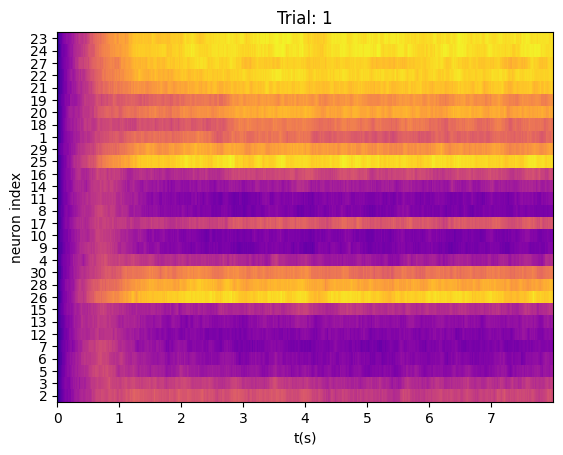

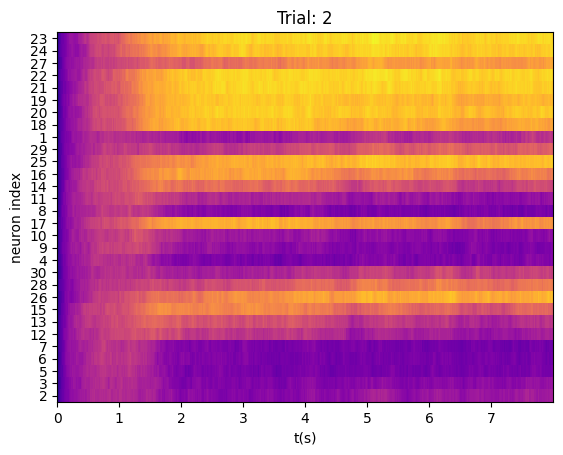

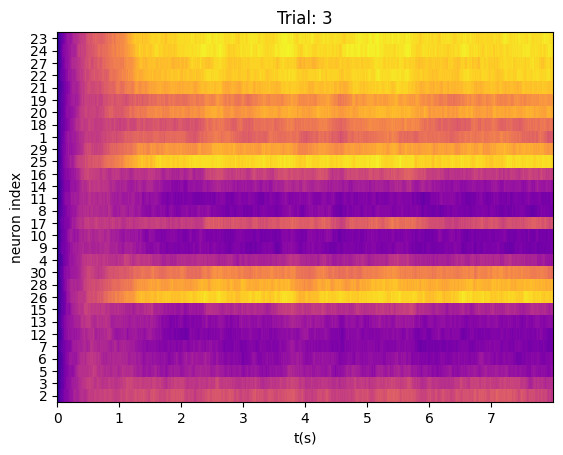

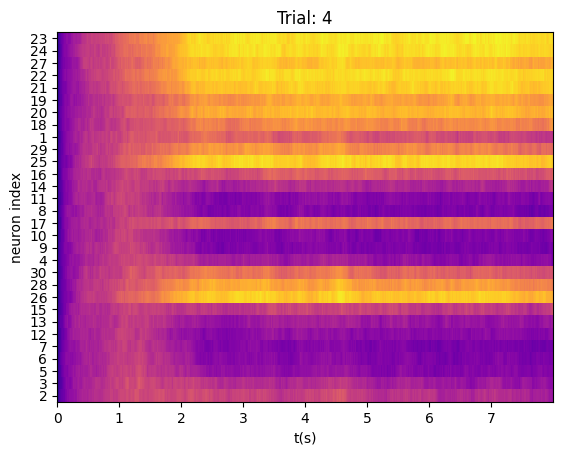

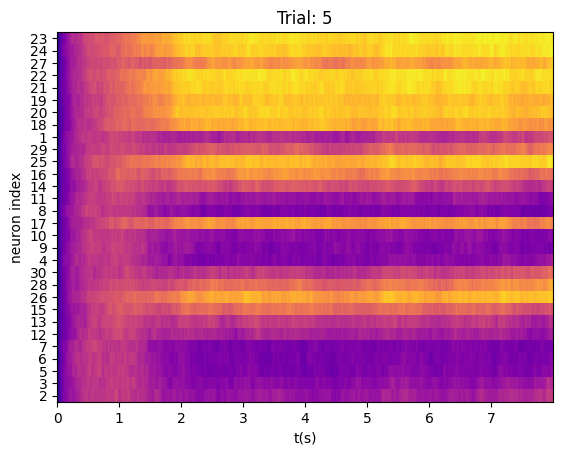

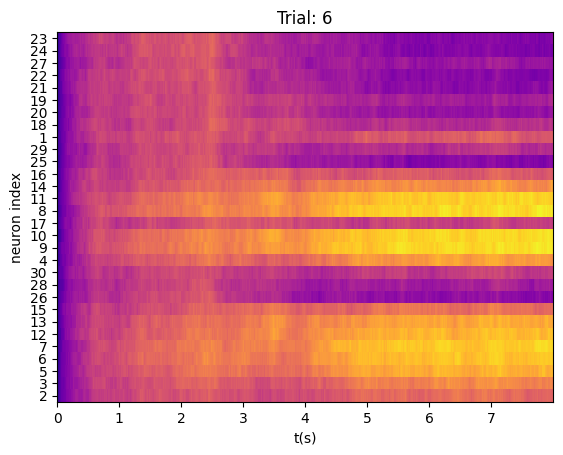

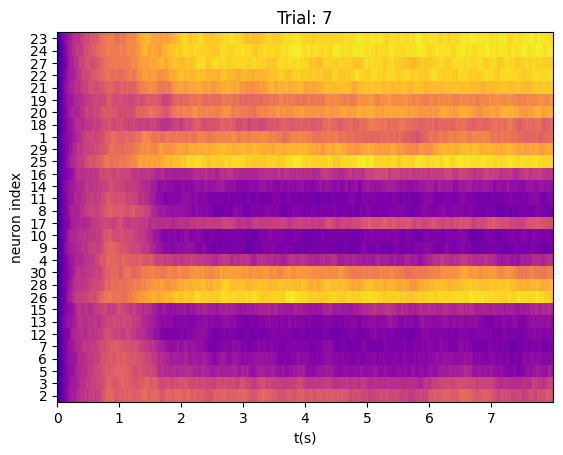

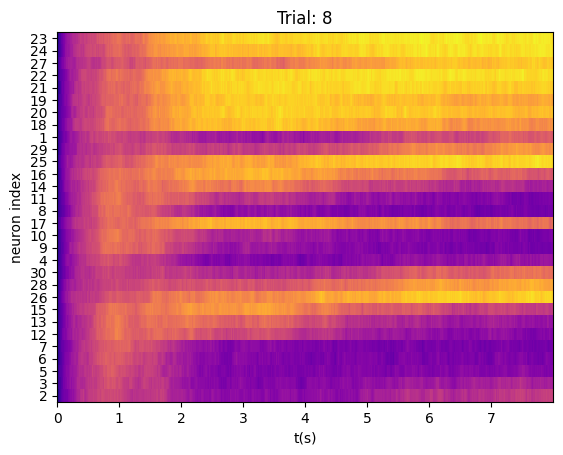

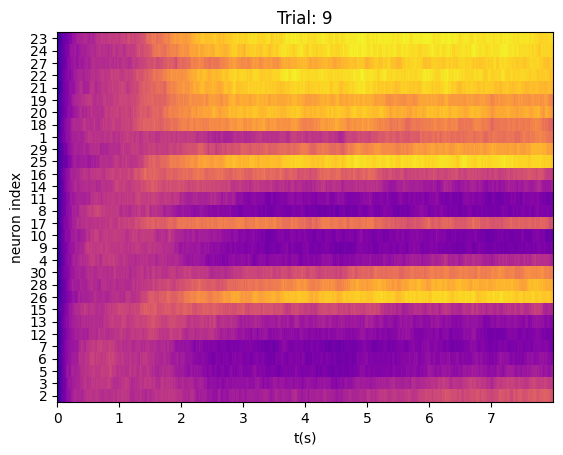

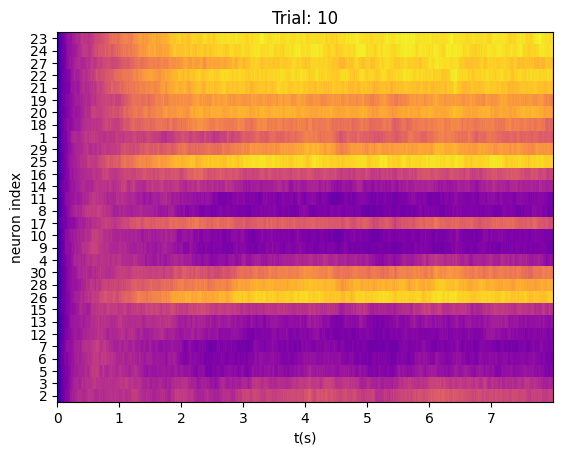

In [4]:
start_scope()


num_trial=10

for trial in range(num_trial):
    test_set=[]
    control=[]
    L=2 #local domain
    U=L+1

    #initial conditions
    light=0       ###10^-8


    n=31 #num of neurons
    jump=2 #spacing

    slope=5               
    t=46*ms           
    threshold=540
    mean=105 ##
    std=400   ##      

    w_I=-380      
    w_Eb=20           
    w_Ew=292.5 ## 


    #simulation
    eqs='''
    dr/dt = ( - r + 1/(1+exp(-a*(Isyn+Iin-theta+mu+sigma*randn())))) / tau : 1
    Iin : 1
    Isyn : 1
    theta : 1
    a : 1
    sigma : 1
    tau : second
    mu : 1
    '''

    G=NeuronGroup(n, eqs, method='euler');


    G.r = 0.0
    G.tau=t
    G.Iin=0
    G.Iin[15]=light
    G.theta=threshold
    G.a=slope
    G.mu=mean
    G.sigma=std


    S = Synapses(G, G, '''
                w : 1 # synaptic weight
                Isyn_post = w * r_pre : 1 (summed)
                ''')

    I=[];J=[]
    for syn in range(1,n):
        I.append(syn)
        J.append(0)
    for syn in range(1,n):
        I.append(0)
        J.append(syn)

    for syn in range(1,n):
        if syn < (n-1):
            I.append(syn)
            J.append(syn+1)
        else:
            I.append(syn)
            J.append(1)
    if n>3:
        for syn in range(n-1,0,-1):
            if syn>1:
                I.append(syn)
                J.append(syn-1)
            else:
                I.append(syn)
                J.append(n-1)
    if n>4:
        for syn in range(1,n):
            if (syn+jump) <= (n-1):
                I.append(syn)
                J.append(syn+jump)
            else:
                I.append(syn)
                J.append(syn-(n-1-jump))
    if n>5:
        for syn in range(n-1,0,-1):
            if syn>jump:
                I.append(syn)
                J.append(syn-2)
            else:
                I.append(syn)
                J.append(syn+(n-1-jump))



    S.connect(i=I,j=J)


    for syn in np.arange(n-1):
        S.w[syn]=w_Eb


    for syn in np.arange(n-1, 2*n-2):
        S.w[syn]=w_I

    i=0
    for syn in np.arange(2*n-2,len(S.w)):
        S.w[syn]=w_Ew_randn[i]
        i+=1

    M = StateMonitor(G, 'r', record=True)

    run(8000*ms)

    figure()
    neuron_index=range(1,n)
    pc=pcolormesh(M.t,neuron_index,M.r[indexs],cmap='plasma', shading='auto')
    title(f'Trial: {trial+1}')
    xlabel('t(s)')
    ylabel('neuron index')
    yticks(ticks=range(1,31), labels=indexs)
    show();

### 2. Trial-one-based approach

{10: 0.20588829414030244, 11: 0.20764922215752168, 9: 0.20916310793916906, 12: 0.21077078570851723, 8: 0.22036177822503228, 13: 0.22934346621322804, 7: 0.2334378788632152, 14: 0.25454839189237344, 6: 0.26624576297714736, 15: 0.2972357624018498, 5: 0.3056295626964188, 16: 0.3527757800504051, 4: 0.37256692744367315, 17: 0.4050102046386388, 3: 0.43131150375282595, 18: 0.4854413361347824, 2: 0.5050319762494869, 19: 0.5623507522523965, 1: 0.595609002203767, 30: 0.6337941216983254, 20: 0.6343568267134927, 21: 0.7013778642707369, 29: 0.7054384890241217, 28: 0.7336148527397653, 22: 0.7558038978869284, 26: 0.7837035981723186, 27: 0.7857910068265214, 25: 0.7929198503977408, 23: 0.7934523933548701, 24: 0.7982801926513001}


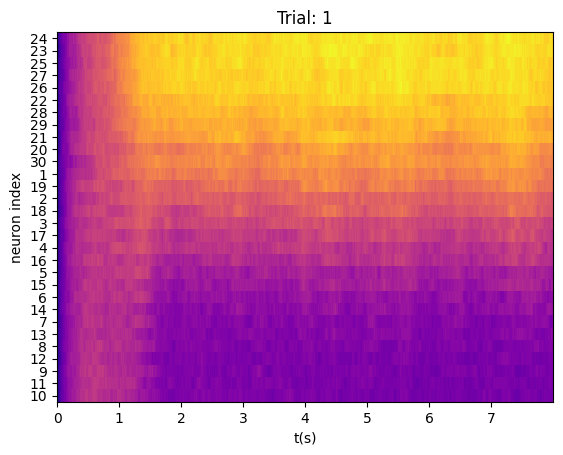

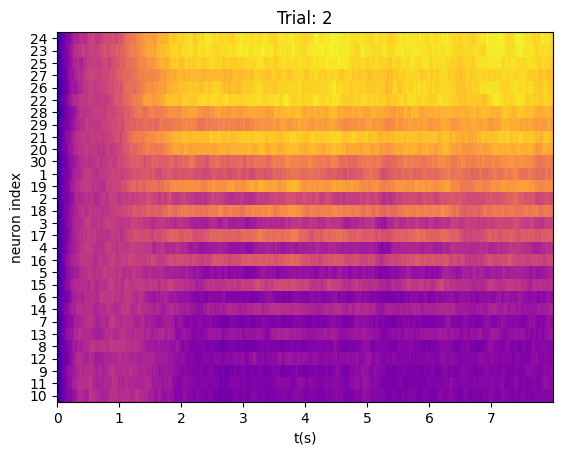

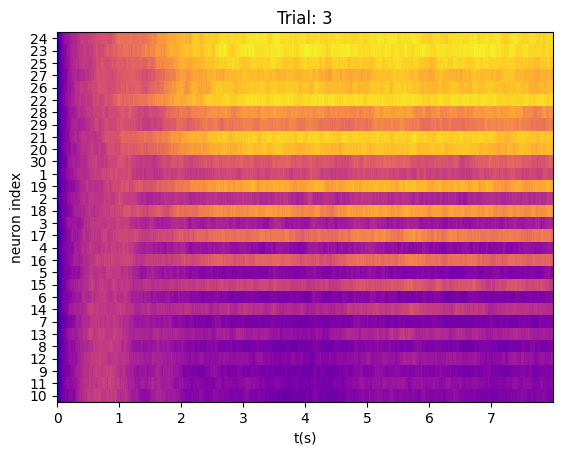

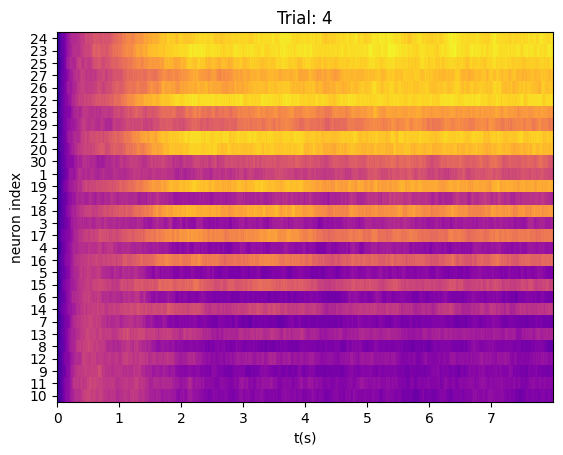

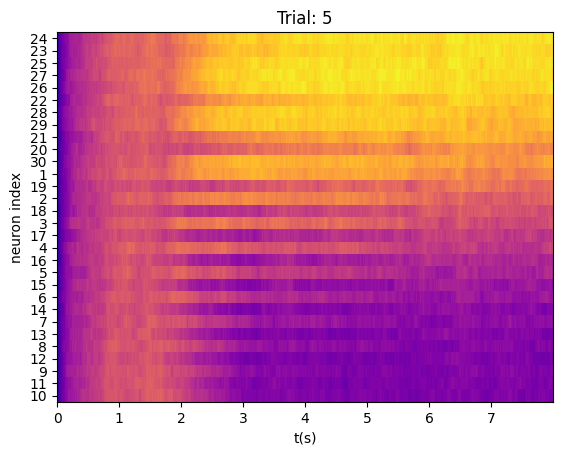

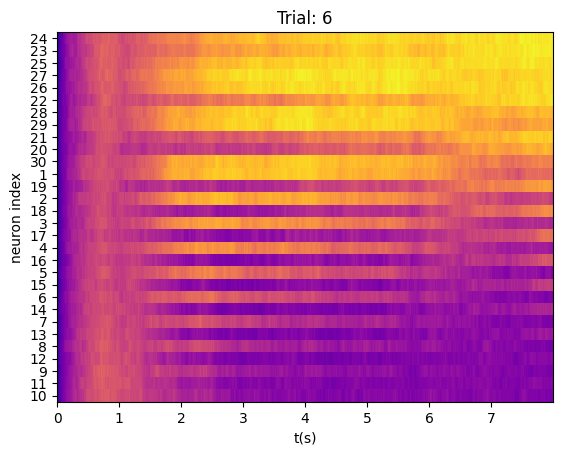

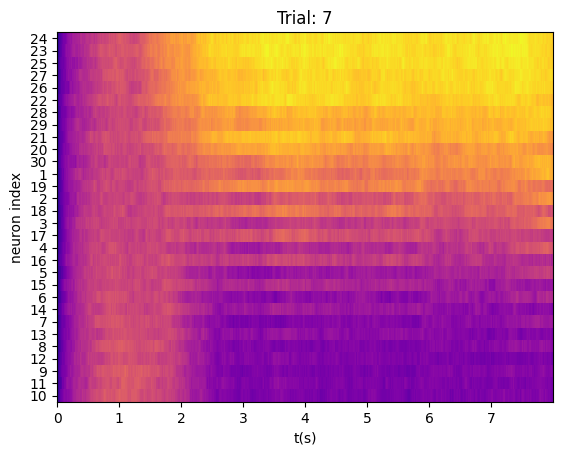

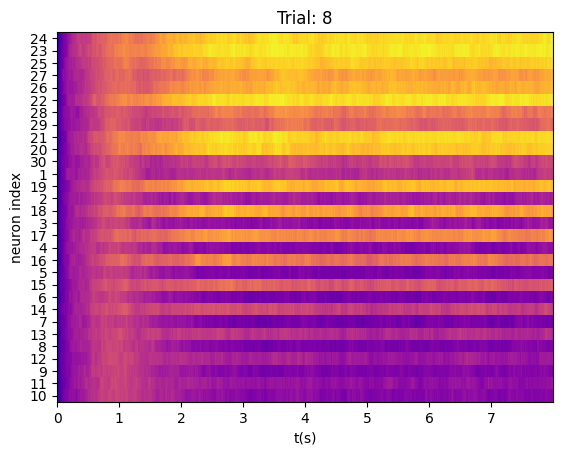

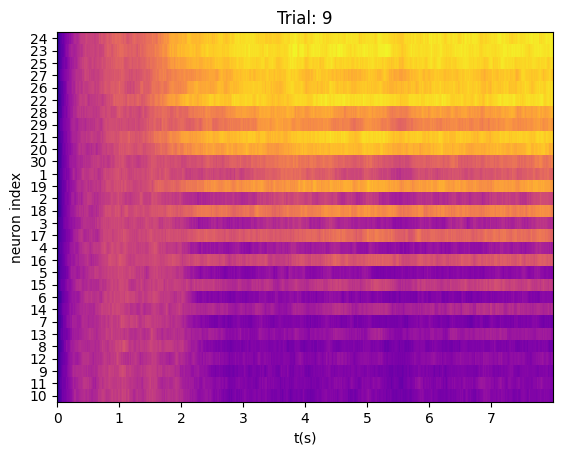

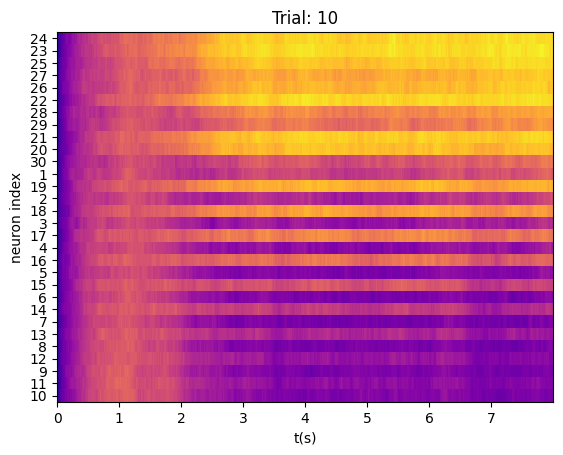

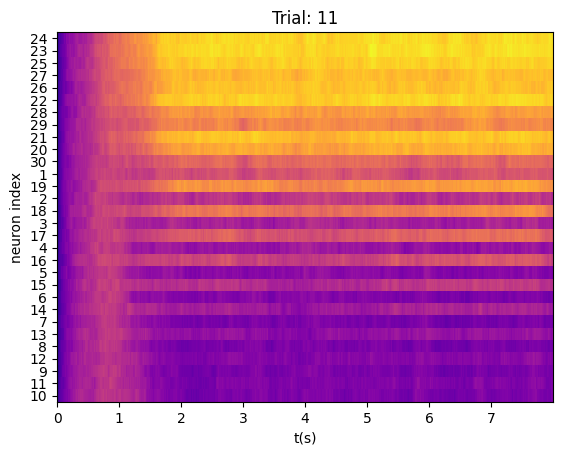

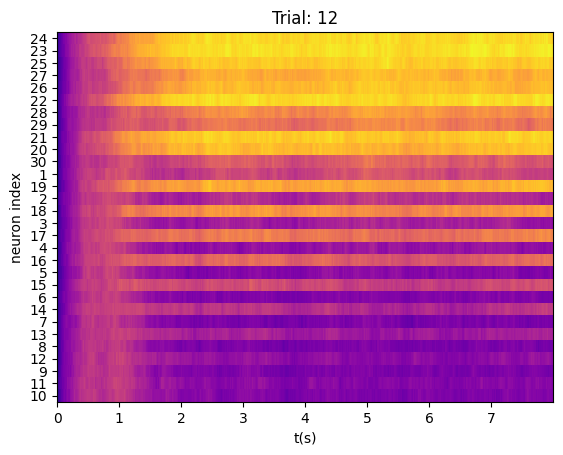

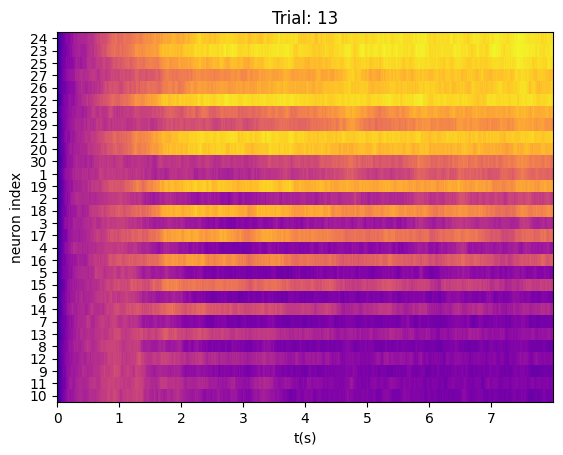

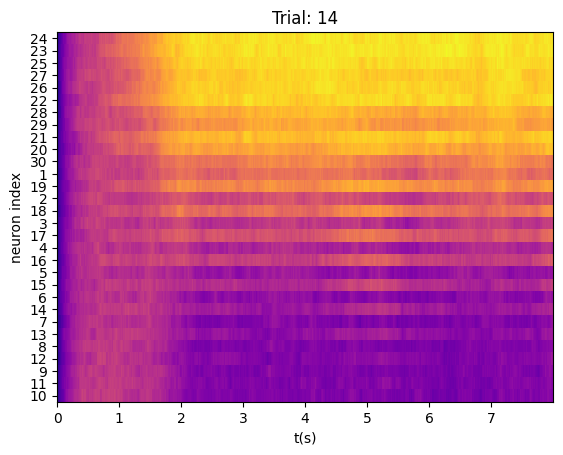

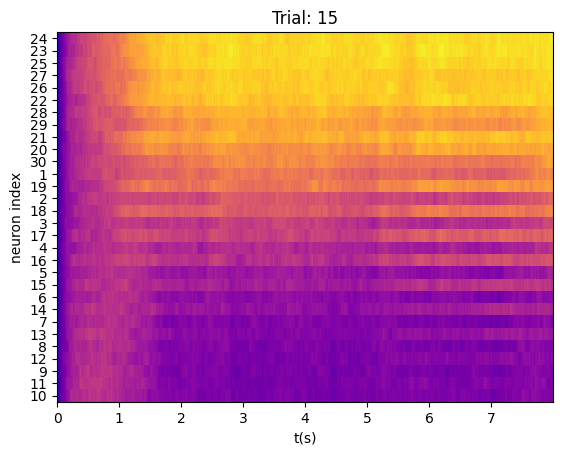

In [5]:
start_scope()


num_trial=15


test_set=[]
control=[]
L=2 #local domain
U=L+1

#initial conditions
light=0       ###10^-8


n=31 #num of neurons
jump=2 #spacing

slope=5               
t=46*ms           
threshold=540
mean=105 ##
std=400   ##      

w_I=-380      
w_Eb=20           
w_Ew=292.5 ## 


#simulation
eqs='''
dr/dt = ( - r + 1/(1+exp(-a*(Isyn+Iin-theta+mu+sigma*randn())))) / tau : 1
Iin : 1
Isyn : 1
theta : 1
a : 1
sigma : 1
tau : second
mu : 1
'''

G=NeuronGroup(n, eqs, method='euler');


G.r = 0.0
G.tau=t
G.Iin=0
G.Iin[15]=light
G.theta=threshold
G.a=slope
G.mu=mean
G.sigma=std


S = Synapses(G, G, '''
            w : 1 # synaptic weight
            Isyn_post = w * r_pre : 1 (summed)
            ''')

I=[];J=[]
for syn in range(1,n):
    I.append(syn)
    J.append(0)
for syn in range(1,n):
    I.append(0)
    J.append(syn)

for syn in range(1,n):
    if syn < (n-1):
        I.append(syn)
        J.append(syn+1)
    else:
        I.append(syn)
        J.append(1)
if n>3:
    for syn in range(n-1,0,-1):
        if syn>1:
            I.append(syn)
            J.append(syn-1)
        else:
            I.append(syn)
            J.append(n-1)
if n>4:
    for syn in range(1,n):
        if (syn+jump) <= (n-1):
            I.append(syn)
            J.append(syn+jump)
        else:
            I.append(syn)
            J.append(syn-(n-1-jump))
if n>5:
    for syn in range(n-1,0,-1):
        if syn>jump:
            I.append(syn)
            J.append(syn-2)
        else:
            I.append(syn)
            J.append(syn+(n-1-jump))



S.connect(i=I,j=J)


for syn in np.arange(n-1):
    S.w[syn]=w_Eb


for syn in np.arange(n-1, 2*n-2):
    S.w[syn]=w_I

i=0
for syn in np.arange(2*n-2,len(S.w)):
    S.w[syn]=w_Ew_randn[i]
    i+=1

M = StateMonitor(G, 'r', record=True)

run(8000*ms)
activity=[]
for i in range(1, n):
    activity.append(np.mean(M.r[i][20000:]))

activity_dict = {index+1: value for index, value in enumerate(activity)}

# Sort dictionary by values
sorted_activity_dict = dict(sorted(activity_dict.items(), key=lambda item: item[1], reverse=False)) #small->big

print(sorted_activity_dict)
indexs=list(sorted_activity_dict.keys())



figure()
neuron_index=range(1,n)
pc=pcolormesh(M.t,neuron_index,M.r[indexs],cmap='plasma', shading='auto');
xlabel('t(s)')
ylabel('neuron index')
yticks(ticks=range(1,31), labels=indexs)
title('Trial: 1')
show()

# present in the same order according to 1st trial
for trial in range(num_trial-1):
    test_set=[]
    control=[]
    L=2 #local domain
    U=L+1

    #initial conditions
    light=0       ###10^-8


    n=31 #num of neurons
    jump=2 #spacing

    slope=5               
    t=46*ms           
    threshold=540
    mean=105 ##
    std=400   ##      

    w_I=-380      
    w_Eb=20           
    w_Ew=292.5 ## 


    #simulation
    eqs='''
    dr/dt = ( - r + 1/(1+exp(-a*(Isyn+Iin-theta+mu+sigma*randn())))) / tau : 1
    Iin : 1
    Isyn : 1
    theta : 1
    a : 1
    sigma : 1
    tau : second
    mu : 1
    '''

    G=NeuronGroup(n, eqs, method='euler');


    G.r = 0.0
    G.tau=t
    G.Iin=0
    G.Iin[15]=light
    G.theta=threshold
    G.a=slope
    G.mu=mean
    G.sigma=std


    S = Synapses(G, G, '''
                w : 1 # synaptic weight
                Isyn_post = w * r_pre : 1 (summed)
                ''')

    I=[];J=[]
    for syn in range(1,n):
        I.append(syn)
        J.append(0)
    for syn in range(1,n):
        I.append(0)
        J.append(syn)

    for syn in range(1,n):
        if syn < (n-1):
            I.append(syn)
            J.append(syn+1)
        else:
            I.append(syn)
            J.append(1)
    if n>3:
        for syn in range(n-1,0,-1):
            if syn>1:
                I.append(syn)
                J.append(syn-1)
            else:
                I.append(syn)
                J.append(n-1)
    if n>4:
        for syn in range(1,n):
            if (syn+jump) <= (n-1):
                I.append(syn)
                J.append(syn+jump)
            else:
                I.append(syn)
                J.append(syn-(n-1-jump))
    if n>5:
        for syn in range(n-1,0,-1):
            if syn>jump:
                I.append(syn)
                J.append(syn-2)
            else:
                I.append(syn)
                J.append(syn+(n-1-jump))



    S.connect(i=I,j=J)


    for syn in np.arange(n-1):
        S.w[syn]=w_Eb


    for syn in np.arange(n-1, 2*n-2):
        S.w[syn]=w_I

    i=0
    for syn in np.arange(2*n-2,len(S.w)):
        S.w[syn]=w_Ew_randn[i]
        i+=1

    M = StateMonitor(G, 'r', record=True)

    run(8000*ms)

    figure()
    neuron_index=range(1,n)
    pc=pcolormesh(M.t,neuron_index,M.r[indexs],cmap='plasma', shading='auto')
    title(f'Trial: {trial+2}')
    xlabel('t(s)')
    ylabel('neuron index')
    yticks(ticks=range(1,31), labels=indexs)
    show();